In [ ]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('SampleSuperstore.csv')

# 2. View the first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# 3. Check column names, data types, and non-null counts
print("\n--- Data Info ---")
df.info()

# 4. Check for missing values in each column
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- First 5 Rows ---


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB

--- Missing Values ---
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category      

In [ ]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('SampleSuperstore.csv')

# 2. Clean column names (strip trailing spaces if any)
df.columns = df.columns.str.strip()

# 3. Check for duplicates
df = df.drop_duplicates()

# 4. Feature Engineering (New Columns)
# Unit Price = Total Sales / Quantity
df['Unit Price'] = (df['Sales'] / df['Quantity']).round(2)

# Profit Margin % = (Profit / Sales) * 100
df['Profit Margin %'] = ((df['Profit'] / df['Sales']) * 100).round(2)

# 5. Preview first 5 rows
print("--- Cleaned Dataset Preview ---")
display(df.head())

# 6. Save the cleaned CSV
df.to_csv('CleanedDataSuperstore.csv', index=False)
print("\nSaved as 'data/cleaned_superstore.csv' successfully!")

--- Cleaned Dataset Preview ---


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Unit Price,Profit Margin %
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,130.98,16.00
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,243.98,30.00
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,7.31,47.00
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,191.52,-40.00
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.18,11.25



Saved as 'data/cleaned_superstore.csv' successfully!


<Figure size 900x500 with 0 Axes>

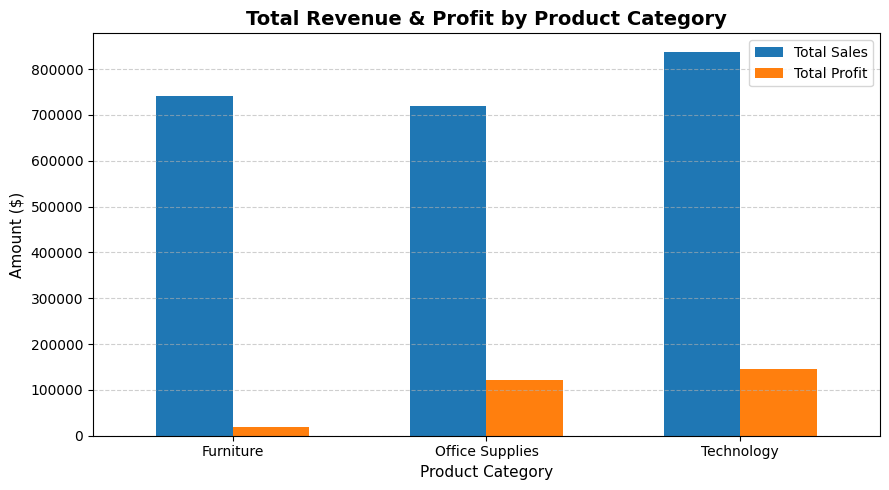

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the cleaned data
df = pd.read_csv('CleanedDataSuperstore.csv')

# 2. Group by category and calculate total sales & profit
# (Ensures case-insensitive matching for column names)
df.columns = df.columns.str.lower()
category_summary = df.groupby('category')[['sales', 'profit']].sum()

# 3. Create a clean double bar plot
plt.figure(figsize=(9, 5))
ax = category_summary.plot(kind='bar', figsize=(9, 5), width=0.6)

plt.title('Total Revenue & Profit by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Amount ($)', fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(['Total Sales', 'Total Profit'])
plt.tight_layout()

